# Do OPEC meetings really move oil? 🛢️
### The announcement-day folklore — louder, yes; tradable, no — in plain English

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Vol_doubles%3F: Busted](https://img.shields.io/badge/Vol_doubles%3F-Busted-8b949e?style=flat-square)

Every few months, oil ministers file into a room in Vienna (or a videoconference), argue about production quotas, and the world's energy desks hold their breath. The folklore says two things about those days: **volatility doubles**, and the move after the decision **keeps going** — so you can "trade the announcement."

We froze the *entire* calendar of OPEC and OPEC+ ministerial decision days since 2000 — **107 meetings**, from the March 2000 quota raise to the June 2026 OPEC+ meeting — and put both halves of the folklore against three oil tapes: WTI futures, Brent futures, and the USO ETF.

> 📓 **Plain-language layer.** Want the *t*-stats, the bootstrap CIs and the HAC regressions? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from opec_announcement_effect import data, strategy as st

AS_OF = "2026-06-30"
DATES = data.meeting_dates()
HAVE_REAL = data.have_real()
TAPES = data.load_real(asof=AS_OF) if HAVE_REAL else {}
print("real tapes cached:", HAVE_REAL, "| meetings:", len(DATES),
      f"({DATES.min().date()} -> {DATES.max().date()})")

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_meetings': 107, 'first': '2000-03-28', 'last': '2026-06-07', 'fp_cl': '1a2103f8c32a', 'fp_bz': '7e9543880619', 'fp_uso': '6976f7deb0d1', 'vol': {'CL': (105, 248.3, 177.1, 1.4, 1.15, 1.67, 3.07, 2.84, 1.23, 0.018, 1.45, 4.8), 'BZ': (68, 242.2, 158.0, 1.53, 1.21, 1.89, 3.01, 2.57, 2.12, 0.0, 1.52, 4.23), 'USO': (73, 242.1, 159.8, 1.52, 1.2, 1.85, 3.17, 3.09, 2.15, 0.0, 1.47, 3.64)}, 'drift': {'CL': [(0, -11.2, -0.3), (1, -50.3, -0.92), (2, -20.5, -0.16), (3, 16.6, 0.51), (5, -215.4, -0.89)], 'BZ': [(0, -0.1, -0.07), (1, -65.2, -1.15), (2, -47.2, -0.7), (3, -35.9, -0.44), (5, -50.0, -0.63)], 'USO': [(0, -14.2, -0.36), (1, -57.3, -0.9), (2, -39.3, -0.46), (3, -37.7, -0.34), (5, -31.5, -0.16)]}, 'cont': {'CL': (105, 365.0, 1.4, 61, 67.2, 1.29, 0.95, 1.27, 1.4), 'BZ': (68, 136.2, 1.69, 60, 111.5, 1.62, 0.87, 1.45, 0.58), 'USO': (73, 158.1, 2.2, 56, 70.7, 1.19, 0.68, 2.25, 1.91)}, 'cl_net': [(2.0, 361.0), (5.0, 355.0), (10.0, 345.0)], 'syn': [('null (x1)', 0.96, -0.51, 0.688, -6.3, -0.22), ('vol x2 planted', 1.92, 6.12, 0.0, -12.6, -0.26), ('x2 + drift +150', 2.01, 6.33, 0.0, 137.4, 3.22)]}


real tapes cached: True | meetings: 107 (2000-03-28 -> 2026-06-07)


## The answer first

| Question | Answer |
|---|---|
| Are OPEC decision days louder than normal days? | **Yes — really.** About **1.4–1.5× louder** on all three tapes, and that's statistically solid, not luck. |
| Does volatility *double*, like the folklore says? | **No.** ~1.5× is the honest number; a genuine doubling would have lit our tests up far harder (we checked, by planting one in a simulator). |
| Does oil drift after the decision? | **No.** Up-days and down-days cancel almost perfectly — at every horizon from the decision day to a week later, the average move is statistically **zero**. |
| Can you "trade the announcement" (ride the day-0 direction)? | **Not honestly.** The rule only looks good if the five wild meetings of 2020 are in the sample. Remove them and it's noise. |

> The folklore is **half right**: OPEC days are genuinely louder. The half you could monetise — the doubling, the drift — isn't there.

## 1 · The claim

> *"OPEC meeting days move oil. Vol doubles on decision day, and once the decision is out, the move keeps going — get on it."*

It's plausible folklore. OPEC(+) controls a big slice of world production; its decisions are scheduled, public, and occasionally shocking (the no-cut of November 2014, the price war of March 2020, the surprise 2-million-barrel cut of October 2022). The academic literature agrees the days are *special* — but is vague on how special, and quietly split on whether anything is left to trade once the decision hits the tape.

## 2 · So what?

Two different products are being sold in one sentence. **"Vol doubles"** is a claim about *risk* — it tells you what options should cost and how wide your stops must be. **"The drift is tradable"** is a claim about *direction* — free money if true. A desk that conflates them buys expensive straddles *and* chases moves that don't continue. We test each on its own.

## 3 · How would we even know?

- **The calendar.** All **107** OPEC Conference + OPEC+ ministerial decision days 2000–2026, hardcoded from the OPEC press-release archive (weekend meetings roll to the next trading day).
- **Louder?** Compare the size of the day-0 move (and the intraday high-low range) against ordinary days far from any meeting.
- **Drift?** Average the *signed* move from the day before the decision to 1–5 days after. If announcements start trends, this is where they'd show.
- **Tradable?** Follow the day-0 direction for a week, after realistic futures costs — and check the rule survives without 2020, the wildest year in oil history.

## 4 · The teardown — let's actually look

**First: are decision days louder?** Average |daily move| on OPEC decision days vs ordinary days, per tape.

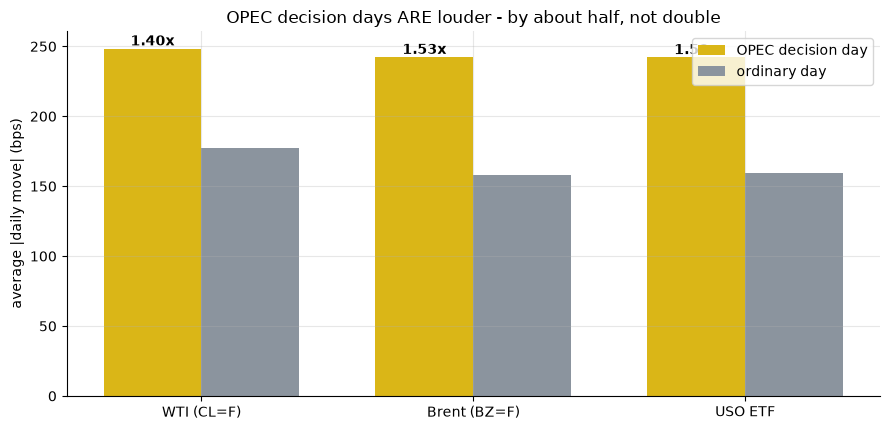

vol multiples: ['1.40x', '1.53x', '1.52x']


In [2]:
labs = ['WTI (CL=F)', 'Brent (BZ=F)', 'USO ETF']
keys = ['CL', 'BZ', 'USO']
if HAVE_REAL:
    rows = [st.vol_stats(TAPES[tk], DATES, n_boot=200, n_placebo=200)
            for tk in ('CL=F', 'BZ=F', 'USO')]
    ev = [r['abs_ev_bps'] for r in rows]; ba = [r['abs_base_bps'] for r in rows]
else:
    ev = [R['vol'][k][1] for k in keys]; ba = [R['vol'][k][2] for k in keys]
x = np.arange(3); w = .36
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x - w/2, ev, w, color=AMBER, label='OPEC decision day')
ax.bar(x + w/2, ba, w, color=GREY, label='ordinary day')
for i in range(3):
    ax.annotate(f'{ev[i]/ba[i]:.2f}x', (i - w/2, ev[i]), ha='center', va='bottom', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labs); ax.set_ylabel('average |daily move| (bps)')
ax.set_title('OPEC decision days ARE louder - by about half, not double')
ax.legend(); plt.tight_layout(); plt.show()
print('vol multiples:', [f'{e/b:.2f}x' for e, b in zip(ev, ba)])

Louder — genuinely. WTI moves **248 bps** on decision days vs **177 bps** normally (**1.40×**); Brent and USO read **1.53×** and **1.52×**. The quants notebook shows this clears the significance bar comfortably on all three tapes. But notice what it *isn't*: **2×**. The folklore's "vol doubles" is half again too generous.

**Second: is there a drift to ride?** The average *signed* move after the decision, from the day before to 0–5 days after. Loud days can still average to zero — if cuts rally and collapses crash, the mean nets out.

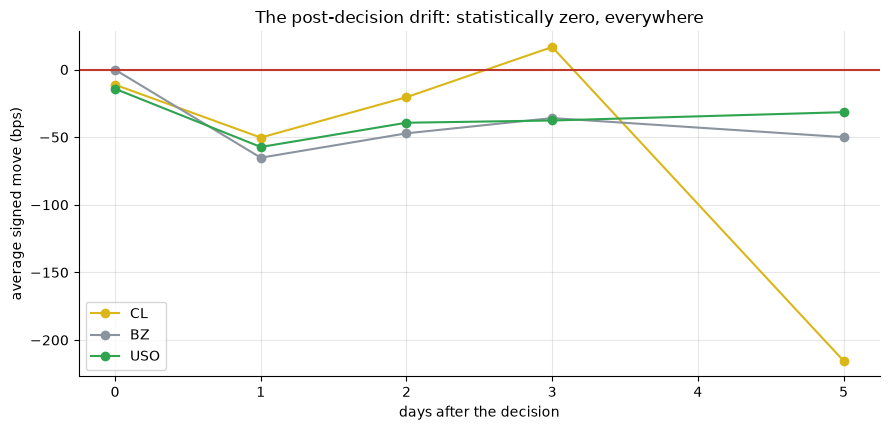

{'CL': [np.float64(-11.2), np.float64(-50.3), np.float64(-20.5), np.float64(16.6), np.float64(-215.4)], 'BZ': [np.float64(-0.1), np.float64(-65.2), np.float64(-47.2), np.float64(-35.9), np.float64(-50.0)], 'USO': [np.float64(-14.2), np.float64(-57.3), np.float64(-39.3), np.float64(-37.7), np.float64(-31.5)]}


In [3]:
ks = [0, 1, 2, 3, 5]
if HAVE_REAL:
    drift = {lab: [d['mean_bps'] for d in st.drift_stats(TAPES[tk], DATES)]
             for lab, tk in zip(keys, ('CL=F', 'BZ=F', 'USO'))}
else:
    drift = {k: [row[1] for row in R['drift'][k]] for k in keys}
fig, ax = plt.subplots(figsize=(9.0, 4.4))
for k, c in zip(keys, [AMBER, GREY, GREEN]):
    ax.plot(ks, drift[k], 'o-', color=c, label=k)
ax.axhline(0, c=RED, lw=1.5)
ax.set_xlabel('days after the decision'); ax.set_ylabel('average signed move (bps)')
ax.set_title('The post-decision drift: statistically zero, everywhere')
ax.legend(); plt.tight_layout(); plt.show()
print({k: [round(v, 1) for v in drift[k]] for k in keys})

Wiggles around zero, never significant — the quants notebook runs the proper (autocorrelation-robust) test on all **15** horizon-×-tape combinations and every single one sits **far below the significance bar**. OPEC days are loud, but they are loud in *both directions*, and the directions cancel.

**Third: the "trade the announcement" rule.** Go with the day-0 direction, hold five days. Here's the trick the folklore plays — watch what happens when we remove the five meetings of 2020 (the price war and the historic 9.7 mb/d cut):

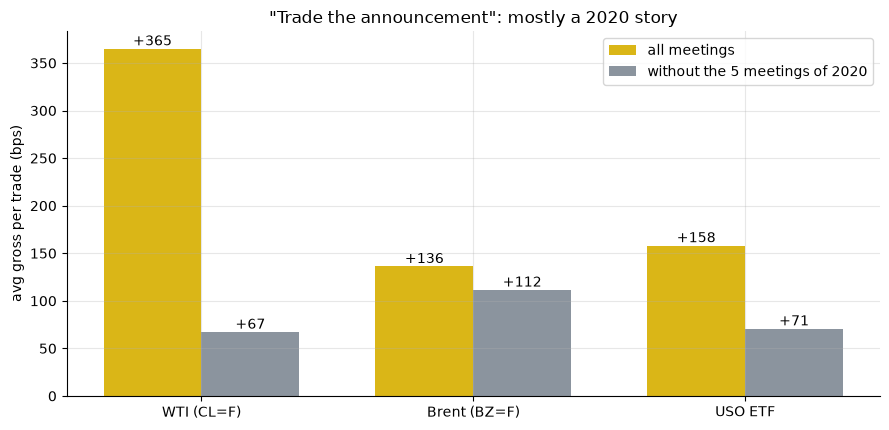

all: [365, 136, 158]  ex-2020: [67, 112, 71]


In [4]:
if HAVE_REAL:
    no20 = DATES[(DATES < '2020-01-01') | (DATES > '2020-12-31')]
    g_all = [st.continuation_stats(TAPES[tk], DATES)['gross_bps'] for tk in ('CL=F','BZ=F','USO')]
    g_ex  = [st.continuation_stats(TAPES[tk], no20)['gross_bps'] for tk in ('CL=F','BZ=F','USO')]
else:
    g_all = [R['cont'][k][1] for k in keys]; g_ex = [R['cont'][k][4] for k in keys]
x = np.arange(3); w = .36
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x - w/2, g_all, w, color=AMBER, label='all meetings')
ax.bar(x + w/2, g_ex, w, color=GREY, label='without the 5 meetings of 2020')
for i in range(3):
    ax.annotate(f'{g_all[i]:+.0f}', (i - w/2, g_all[i]), ha='center', va='bottom')
    ax.annotate(f'{g_ex[i]:+.0f}', (i + w/2, g_ex[i]), ha='center', va='bottom')
ax.set_xticks(x); ax.set_xticklabels(labs); ax.set_ylabel('avg gross per trade (bps)')
ax.set_title('"Trade the announcement": mostly a 2020 story')
ax.legend(); plt.tight_layout(); plt.show()
print('all:', [round(v) for v in g_all], ' ex-2020:', [round(v) for v in g_ex])

On WTI the average "edge" falls from **+365** to **+67 bps** per trade without 2020 — and it was never statistically significant to begin with (*t* ≈ 1.4). The one cell that grazes significance (USO, *t* = 2.20) collapses to *t* = 1.19 ex-2020. Costs aren't the problem — the *signal* is: a rule that needs five specific meetings from the wildest year in oil history is not a rule.

## 5 · The verdict

- **Signal — Mixed.** *Real on the vol:* decision days run **1.4–1.5× louder** on all three tapes, comfortably significant. *None on the drift:* the signed post-decision move is zero at every horizon.
- **Tradability — Mirage.** No drift to harvest; the day-0-direction rule is a 2020 artifact; and the extra vol is exactly when option protection is priced up.
- **"Vol doubles"? — Busted.** **~1.5×**, measured with confidence intervals that exclude 2× on every tape. Louder, yes. Doubled, no.

## 6 · Going further 🚪

- **Why no drift?** OPEC decisions are *scheduled* news — desks pre-position for weeks, and the surprise is absorbed within the session. What's left is variance, not direction. Compare [313-geopolitical-shock](../../313-geopolitical-shock/) — *unscheduled* oil shocks — and [226-crude-seasonality](../../226-crude-seasonality/) for the calendar-time cousin.
- **The vol IS real information.** 1.5× isn't tradable as direction, but it prices straddles, sizes stops, and warns you off tight-stop positions into a meeting.
- **Build your own.** The full 107-meeting table lives in [`data.py`](../opec_announcement_effect/data.py) with sources — swap in decision labels (cut/raise/hold) and test the asymmetry the literature reports.

*Think the announcement is tradable with a finer clock? Show a rule that clears *t* = 2 on intraday data **without** 2020 in the sample — then we'll talk.*